# `neutral_yb` src API tutorial：从源码入口复现三条当前结果线

本教程面向当前 Python 项目 `/home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization` 中的 `src/neutral_yb/`。目标不是重新开发模型，而是展示如何直接调用当前 `src` 中已经封装好的模型、优化器、扫描和 artifact API，复现仓库当前保留的三条结果线，并说明哪些参数可以安全改到其他问题。

三条主线是：

- `v1`：理想 4D global `CZ` 的无噪声 phase-only GRAPE 正确性基准。
- `evered2023_parallel_cz`：Evered et al. 2023 fixed-amplitude phase family 的参数化 GRAPE 复现/验证线。
- `yb171_uv_edge_scan`：`^{171}Yb` shelved control-Rydberg 段的 UV Gaussian edge 扫描。

本 notebook 已保存执行输出。完整重跑 dense scan 或大规模 GRAPE 会比较耗时，所以教程默认读取已有 artifact，并只执行轻量 API 验证。需要完整重跑时，使用后文给出的命令或把对应开关改为 `True`。


## Goal and relation to `^{171}Yb` nuclear-spin quantum computation

`^{171}Yb` 核自旋量子计算的门方案通常把长寿命 clock/nuclear-spin 态作为计算态，再通过 shelving、UV Rydberg 激发、unshelving 等步骤实现双比特相位门。当前 `src/neutral_yb/` 主要保留三类可复现代码：

1. 用一个最小 4D 理想模型验证 GRAPE 管线和 fidelity 目标是否正确。
2. 用 Evered 2023 的 fixed-amplitude phase family 检查带基函数/参数化 GRAPE 是否能恢复文献型 time-optimal pulse。
3. 用 `^{171}Yb` shelved control-Rydberg reduced model 扫描 UV 脉冲边沿，评估 finite rise/fall time 与 Rydberg decay 对 no-jump process fidelity 的影响。

读完本教程后，应该能完成两件事：先从 `src` 调用现有 API 读出/复现当前结果；再通过改 `Config` dataclass、模型 builder 或扫描网格，把同一套 workflow 用到新的门时间、Rabi 频率、blockade、edge time 或噪声参数上。


## 运行环境和路径约定

本教程不依赖固定的绝对路径。推荐在任意一份 `Noise-Tolerant-Quantum-Control-Optimization` checkout 中启动 Jupyter，例如：

```bash
cd /path/to/Noise-Tolerant-Quantum-Control-Optimization
jupyter lab tutorial/neutral_yb_src_api_tutorial.ipynb
```

下面的初始化单元会按顺序寻找项目根目录：

1. 如果设置了 `NEUTRAL_YB_PROJECT_ROOT`，优先使用这个环境变量。
2. 从当前 Jupyter 工作目录开始，向上查找包含 `src/neutral_yb/` 和 `artifacts/` 的目录。
3. 如果已经安装了 `neutral_yb`，尝试从包文件位置反推 editable checkout 根目录。

因此，在不同电脑、不同用户名或不同 checkout 路径下，通常不需要改代码。只有当 notebook 不在项目目录内运行、或只安装了 wheel 而没有本地 `artifacts/` 时，才需要手动设置 `NEUTRAL_YB_PROJECT_ROOT`。


In [1]:
from __future__ import annotations

from pathlib import Path
import csv
import inspect
import json
import math
import os
import sys
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt


def _candidate_project_roots() -> list[Path]:
    candidates: list[Path] = []
    env_root = os.environ.get("NEUTRAL_YB_PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    try:
        import neutral_yb as installed_neutral_yb

        package_file = Path(inspect.getfile(installed_neutral_yb)).resolve()
        for parent in package_file.parents:
            candidates.append(parent)
            if parent.name == "src":
                candidates.append(parent.parent)
    except Exception:
        pass

    unique: list[Path] = []
    seen: set[Path] = set()
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved not in seen:
            unique.append(resolved)
            seen.add(resolved)
    return unique


def _looks_like_neutral_yb_checkout(path: Path) -> bool:
    return (path / "src" / "neutral_yb").is_dir() and (path / "artifacts").is_dir()


PROJECT_ROOT = next(
    (candidate for candidate in _candidate_project_roots() if _looks_like_neutral_yb_checkout(candidate)),
    None,
)
if PROJECT_ROOT is None:
    searched = "\n".join(f"  - {path}" for path in _candidate_project_roots())
    raise FileNotFoundError(
        "找不到 Noise-Tolerant-Quantum-Control-Optimization 项目根目录。\n"
        "请在该项目目录内启动 Jupyter，或设置环境变量 NEUTRAL_YB_PROJECT_ROOT。\n"
        f"已检查候选路径：\n{searched}"
    )

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SRC exists     = {SRC.exists()}")
print(f"artifacts dir  = {ARTIFACT_ROOT}")


PROJECT_ROOT = /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization
SRC exists     = True
artifacts dir  = /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts


In [2]:
from neutral_yb.config.species import idealised_yb171
from neutral_yb.config.artifact_paths import (
    evered2023_parallel_cz_dir,
    v1_artifacts_dir,
    yb171_uv_edge_artifacts_dir,
)
from neutral_yb.models.global_cz_4d import GlobalCZ4DModel
from neutral_yb.models.evered2023_parallel_cz import (
    Evered2023ParallelCZCalibration,
    Evered2023TimeOptimalPulse,
    build_evered2023_ideal_global_cz_model,
    build_evered2023_two_photon_detuning_model,
)
from neutral_yb.optimization.grape import ClosedSystemGRAPE, OpenSystemGRAPE
from neutral_yb.optimization.global_phase_grape import GlobalPhaseOptimizationConfig
from neutral_yb.optimization.evered2023_parameterized_grape import Evered2023ParameterizedGRAPEConfig
from neutral_yb.optimization.shelved_cr_phase_grape import (
    ShelvedCRPhaseGRAPEConfig,
    resample_phase_controls,
    unwrap_for_plot,
)
from neutral_yb.analysis.uv_edge_scan import (
    UVDenseEdgeScanConfig,
    config_metadata,
    dense_time_is_allowed,
    load_uv_edge_artifacts,
    run_uv_edge_scan,
    summarize_uv_edge_rows,
    write_uv_edge_artifacts,
)

print("Core imports succeeded.")


Core imports succeeded.


## API map：先从这里找入口

当前维护入口可以按“模型、优化器、扫描/读写 artifact”分层理解：

- `neutral_yb.models.global_cz_4d.GlobalCZ4DModel`：理想 4D global `CZ` 模型。
- `neutral_yb.optimization.global_phase_grape.ClosedSystemGRAPE.global_phase`：slot-wise phase-only GRAPE，支持 scan durations。
- `neutral_yb.models.evered2023_parallel_cz.*`：Evered 2023 pulse 参数、实验标尺、9D two-photon builder。
- `neutral_yb.optimization.evered2023_parameterized_grape.*`：把 slot-wise GRAPE 梯度链式传到 `A, omega, phi0, delta0, theta` 的参数化优化器。
- `neutral_yb.optimization.shelved_cr_phase_grape.*`：`^{171}Yb` shelved control-Rydberg 6D reduced model 的 direct phase GRAPE。
- `neutral_yb.analysis.uv_edge_scan.*`：dense grid 扫描、summary、JSON/CSV 写出和读入。

`experiments/` 里的脚本只是薄入口：解析参数、调用 `src`、写 artifact。新问题优先改 `Config` 或 builder，不要复制旧 notebook cell。


In [3]:
api_paths = {
    "v1 artifacts": v1_artifacts_dir(PROJECT_ROOT),
    "Evered artifacts": evered2023_parallel_cz_dir(PROJECT_ROOT),
    "Yb171 UV edge artifacts": yb171_uv_edge_artifacts_dir(PROJECT_ROOT),
}
for name, path in api_paths.items():
    print(f"{name:24s}: {path}  exists={path.exists()}")


v1 artifacts            : /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v1  exists=True
Evered artifacts        : /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/evered2023_parallel_cz  exists=True
Yb171 UV edge artifacts : /home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/artifacts/v5/closed_cr_edge_time_optimal_scan  exists=True


## Optimization API：算法入口和物理模型同等重要

当前 `src/neutral_yb/optimization/` 不是只有一个 GRAPE 函数，而是一组按控制参数化和动力学类型拆开的 optimizer。使用时先回答四个问题：

1. 动力学是闭系统、no-jump effective generator，还是完整 Liouvillian channel？
2. 控制变量是每个 slot 独立，还是少数基函数/全局参数？
3. 优化目标是 diagonal CZ process fidelity、average-like fidelity、special-state fidelity，还是 active-subspace channel fidelity？
4. 是否需要 smoothness、curvature、amplitude bound 或 ensemble robustness？

多数 optimizer 的公共模式相同：

```python
model = ...
config = SomeOptimizationConfig(...)
optimizer = SomeOptimizer(model, config)
result = optimizer.optimize(...)
objective, gradient = optimizer.objective_and_gradient(...)
```

`optimize()` 内部通常调用 `scipy.optimize.minimize(..., jac=True, method="L-BFGS-B")`。也就是说主路径依赖解析梯度；有限差分主要出现在测试里，用来验证梯度。


In [4]:
from dataclasses import fields, is_dataclass

from neutral_yb.optimization import (
    AmplitudePhaseOptimizationConfig,
    ClosedSystemGRAPE,
    GlobalPhaseOptimizationConfig,
    LinearControlOptimizationConfig,
    OpenSystemGRAPE,
    OpenSystemGRAPEConfig,
    ShelvedCRPhaseGRAPEConfig,
)
from neutral_yb.optimization.evered2023_parameterized_grape import Evered2023ParameterizedGRAPEConfig
from neutral_yb.optimization.ma2023_six_level_grape import Ma2023SixLevelGRAPEConfig

optimizer_catalog = [
    {
        "entry": "ClosedSystemGRAPE.global_phase",
        "config": "GlobalPhaseOptimizationConfig",
        "control": "slot-wise phase(s)",
        "dynamics": "closed state vector",
        "objective": "model.phase_gate_fidelity, current CZ models use process fidelity",
        "gradient": "analytic slot gradient via expm_frechet",
        "typical_model": "GlobalCZ4DModel, two-photon phase-gauge models",
    },
    {
        "entry": "ClosedSystemGRAPE.linear_control",
        "config": "LinearControlOptimizationConfig",
        "control": "slot-wise linear controls",
        "dynamics": "closed state vector",
        "objective": "model.phase_gate_fidelity + optional penalties",
        "gradient": "analytic slot gradient via expm_frechet",
        "typical_model": "models exposing control_hamiltonians()",
    },
    {
        "entry": "ClosedSystemGRAPE.amplitude_phase",
        "config": "AmplitudePhaseOptimizationConfig",
        "control": "slot-wise amplitude + phase",
        "dynamics": "closed state vector",
        "objective": "model.phase_gate_fidelity + amplitude/phase smoothness",
        "gradient": "analytic amplitude/phase gradient via expm_frechet",
        "typical_model": "single phase-control-channel models",
    },
    {
        "entry": "ClosedSystemGRAPE.evered_parameterized",
        "config": "Evered2023ParameterizedGRAPEConfig",
        "control": "A, omega, phi0, optional delta0, theta",
        "dynamics": "closed state vector",
        "objective": "diagonal CZ process fidelity",
        "gradient": "slot gradient chained to global pulse parameters",
        "typical_model": "Evered ideal/two-photon phase family",
    },
    {
        "entry": "ClosedSystemGRAPE.evered_detuning",
        "config": "Evered2023ParameterizedGRAPEConfig",
        "control": "phase-family derivative as two-photon detuning",
        "dynamics": "closed 9D state vector",
        "objective": "detuning-gauge diagonal CZ process fidelity",
        "gradient": "analytic detuning gradient chained to A, omega, phi0",
        "typical_model": "Evered two-photon detuning-gauge 9D model",
    },
    {
        "entry": "ClosedSystemGRAPE.shelved_cr_phase",
        "config": "ShelvedCRPhaseGRAPEConfig",
        "control": "slot-wise UV phase with fixed envelope",
        "dynamics": "closed or no-jump non-Hermitian 6D propagator",
        "objective": "closed average fidelity or no-jump process fidelity",
        "gradient": "analytic phase gradient via expm_frechet",
        "typical_model": "171Yb shelved CR UV edge scan",
    },
    {
        "entry": "OpenSystemGRAPE",
        "config": "OpenSystemGRAPEConfig",
        "control": "slot-wise ctrl_x, ctrl_y, optional envelope",
        "dynamics": "no-jump special state or Liouvillian active channel",
        "objective": "special_state or active_channel",
        "gradient": "analytic state/Liouville gradient via expm_frechet",
        "typical_model": "Yb171ClockRydbergCZOpenModel and ensembles",
    },
    {
        "entry": "ClosedSystemGRAPE.ma2023_six_level_phase",
        "config": "Ma2023SixLevelGRAPEConfig",
        "control": "slot-wise phase with fixed envelope",
        "dynamics": "no-jump/effective six-level propagation",
        "objective": "(4 F_pro + 1 - leakage) / 5",
        "gradient": "analytic phase gradient via expm_frechet",
        "typical_model": "Ma2023 perfect-blockade six-level model",
    },
    {
        "entry": "ClosedSystemGRAPE.ma2023_six_level_chebyshev",
        "config": "Ma2023SixLevelGRAPEConfig",
        "control": "Chebyshev phase-rate coefficients",
        "dynamics": "no-jump/effective six-level propagation",
        "objective": "(4 F_pro + 1 - leakage) / 5",
        "gradient": "analytic slot gradient chained to Chebyshev coefficients",
        "typical_model": "Ma2023 basis-function pulse line",
    },
]

for item in optimizer_catalog:
    print(f"{item['entry']}\n  control  : {item['control']}\n  dynamics : {item['dynamics']}\n  objective: {item['objective']}\n  gradient : {item['gradient']}\n  model    : {item['typical_model']}")


ClosedSystemGRAPE.global_phase
  control  : slot-wise phase(s)
  dynamics : closed state vector
  objective: model.phase_gate_fidelity, current CZ models use process fidelity
  gradient : analytic slot gradient via expm_frechet
  model    : GlobalCZ4DModel, two-photon phase-gauge models
ClosedSystemGRAPE.linear_control
  control  : slot-wise linear controls
  dynamics : closed state vector
  objective: model.phase_gate_fidelity + optional penalties
  gradient : analytic slot gradient via expm_frechet
  model    : models exposing control_hamiltonians()
ClosedSystemGRAPE.amplitude_phase
  control  : slot-wise amplitude + phase
  dynamics : closed state vector
  objective: model.phase_gate_fidelity + amplitude/phase smoothness
  gradient : analytic amplitude/phase gradient via expm_frechet
  model    : single phase-control-channel models
ClosedSystemGRAPE.evered_parameterized
  control  : A, omega, phi0, optional delta0, theta
  dynamics : closed state vector
  objective: diagonal CZ proc

In [5]:
def config_defaults(config_class: type, names: list[str]) -> dict[str, object]:
    if not is_dataclass(config_class):
        raise TypeError(f"{config_class} is not a dataclass")
    defaults = {}
    field_map = {field.name: field for field in fields(config_class)}
    for name in names:
        field = field_map[name]
        if field.default is not field.default_factory:
            defaults[name] = field.default
    return defaults

interesting_config_defaults = {
    "GlobalPhaseOptimizationConfig": config_defaults(
        GlobalPhaseOptimizationConfig,
        ["num_tslots", "evo_time", "max_iter", "fidelity_target", "smoothness_weight", "curvature_weight", "num_restarts"],
    ),
    "Evered2023ParameterizedGRAPEConfig": config_defaults(
        Evered2023ParameterizedGRAPEConfig,
        ["num_tslots", "max_iter", "num_restarts", "include_paper_seed", "fix_static_detuning", "fidelity_target"],
    ),
    "ShelvedCRPhaseGRAPEConfig": config_defaults(
        ShelvedCRPhaseGRAPEConfig,
        ["num_tslots", "blockade_shift_mhz", "smoothness_weight", "curvature_weight", "rydberg_lifetime_s"],
    ),
    "OpenSystemGRAPEConfig": config_defaults(
        OpenSystemGRAPEConfig,
        ["num_tslots", "evo_time", "max_iter", "objective_metric", "control_envelope", "fidelity_target", "num_restarts"],
    ),
    "Ma2023SixLevelGRAPEConfig": config_defaults(
        Ma2023SixLevelGRAPEConfig,
        ["num_tslots", "evo_time", "max_iter", "chebyshev_degree", "fidelity_target", "num_restarts"],
    ),
}

for name, defaults in interesting_config_defaults.items():
    print(name)
    for key, value in defaults.items():
        print(f"  {key}: {value}")


GlobalPhaseOptimizationConfig
  num_tslots: 100
  evo_time: 8.8
  max_iter: 300
  fidelity_target: 0.999
  smoothness_weight: 0.0
  curvature_weight: 0.0
  num_restarts: 1
Evered2023ParameterizedGRAPEConfig
  num_tslots: 160
  max_iter: 260
  num_restarts: 20
  include_paper_seed: False
  fix_static_detuning: True
  fidelity_target: 0.9999
ShelvedCRPhaseGRAPEConfig
  num_tslots: 64
  blockade_shift_mhz: 160.0
  smoothness_weight: 0.0001
  curvature_weight: 0.0001
  rydberg_lifetime_s: None
OpenSystemGRAPEConfig
  num_tslots: 24
  evo_time: 8.8
  max_iter: 120
  objective_metric: special_state
  control_envelope: NONE
  fidelity_target: 0.995
  num_restarts: 3
Ma2023SixLevelGRAPEConfig
  num_tslots: 100
  evo_time: 12.3876
  max_iter: 160
  chebyshev_degree: 13
  fidelity_target: 0.99999
  num_restarts: 4


### 如何选择优化 API

优先按物理问题选择 optimizer，而不是按文件名选择：

- 如果只是检查最小 4D/9D closed-system phase gate，先用 `ClosedSystemGRAPE.global_phase` 或 Evered 参数化 optimizer。
- 如果控制脉冲需要独立优化 `amplitude` 和 `phase`，用 `ClosedSystemGRAPE.amplitude_phase`。
- 如果 Hamiltonian 是 `H_d + sum u_i(t) H_i` 的线性控制形式，用 `ClosedSystemGRAPE.linear_control`。
- 如果问题含 decay 但只需要 no-jump 轨道或 conditional Kraus map，用 `ClosedSystemGRAPE.shelved_cr_phase` 或 Ma/OpenSystem 的 no-jump 路线。
- 如果要优化 density-matrix channel fidelity，使用 `OpenSystemGRAPE(objective_metric="active_channel")`，代价会比 state-vector 目标更高。
- 如果要加基函数，不要在 notebook 里手工把一堆 cell 改掉；参考 Evered 参数化 optimizer 或 `ClosedSystemGRAPE.ma2023_six_level_chebyshev`，把“低维参数 -> slot waveform”的链式梯度写进 optimizer。

下面给出几种模板。它们是调用结构示例，默认不执行长优化。


In [6]:
# Closed-system slot-wise phase template.
closed_template = """
model = GlobalCZ4DModel(species=idealised_yb171())
config = GlobalPhaseOptimizationConfig(num_tslots=100, evo_time=7.6, max_iter=300)
optimizer = ClosedSystemGRAPE.global_phase(model=model, config=config)
result = optimizer.optimize()
"""

# Open-system channel-fidelity template.
open_channel_template = """
from neutral_yb.config import build_yb171_v4_calibrated_model
from neutral_yb.optimization import OpenSystemGRAPE, OpenSystemGRAPEConfig

model = build_yb171_v4_calibrated_model(...)
config = OpenSystemGRAPEConfig(
    num_tslots=24,
    evo_time=8.8,
    objective_metric="active_channel",
    max_iter=120,
)
optimizer = OpenSystemGRAPE(model=model, config=config)
result = optimizer.optimize()
"""

# Basis-function / low-dimensional parameter template.
basis_template = """
config = Evered2023ParameterizedGRAPEConfig(
    num_tslots=160,
    max_iter=260,
    num_restarts=20,
    include_paper_seed=True,
)
optimizer = ClosedSystemGRAPE.evered_detuning(
    model=two_photon_detuning_model,
    omega_t_over_2pi=1.21,
    config=config,
)
result = optimizer.optimize()
"""

print("Closed-system template:")
print(closed_template)
print("Open-system active-channel template:")
print(open_channel_template)
print("Basis-function / parameterized template:")
print(basis_template)


Closed-system template:

model = GlobalCZ4DModel(species=idealised_yb171())
config = GlobalPhaseOptimizationConfig(num_tslots=100, evo_time=7.6, max_iter=300)
optimizer = ClosedSystemGRAPE.global_phase(model=model, config=config)
result = optimizer.optimize()

Open-system active-channel template:

from neutral_yb.config import build_yb171_v4_calibrated_model
from neutral_yb.optimization import OpenSystemGRAPEConfig, OpenSystemGRAPE

model = build_yb171_v4_calibrated_model(...)
config = OpenSystemGRAPEConfig(
    num_tslots=24,
    evo_time=8.8,
    objective_metric="active_channel",
    max_iter=120,
)
optimizer = OpenSystemGRAPE(model=model, config=config)
result = optimizer.optimize()

Basis-function / parameterized template:

config = Evered2023ParameterizedGRAPEConfig(
    num_tslots=160,
    max_iter=260,
    num_restarts=20,
    include_paper_seed=True,
)
optimizer = ClosedSystemGRAPE.evered_detuning(
    model=two_photon_detuning_model,
    omega_t_over_2pi=1.21,
    config=conf

### 梯度、有限差分和目标函数的边界

当前优化主路径使用解析梯度：

- slot-wise propagator 对控制量的导数由 `scipy.linalg.expm_frechet` 给出；
- 参数化 pulse 或 Chebyshev basis 的导数由链式法则从 slot gradient 映射回来；
- smoothness、curvature、amplitude penalty 也有显式梯度；
- 单元测试中的 finite difference 是梯度校验工具，不是默认优化算法。

但这不意味着“任意 fidelity 都自动有解析梯度”。如果把目标函数改成新的实验指标，例如 shot-level loss model、Monte Carlo trajectory average、带 offset 的拟合 benchmark，必须同步实现该目标的梯度，或明确换成无梯度/有限差分优化。当前很多 `to_json()` 中报告的 metric 只是诊断量，不一定是 `optimize()` 正在最大化的目标。


## Physical model I：`v1` ideal 4D global `CZ`

这条线是最小正确性基准。Hilbert space 是对称约化后的 4 维模型，代表 global Rydberg pulse 在 infinite blockade 和无噪声条件下对计算态分支的相位作用。控制 Hamiltonian 写成

```text
H(t) = H_d + Omega [cos(phi_k) H_x + sin(phi_k) H_y]
```

其中 `phi_k` 是每个 time slot 的控制变量。时间单位是无量纲的 `Omega_max * T`，因此 artifact 中的 `evo_time` 不是 ns，而是 `T Omega_max`。这条线不包含 amplitude noise、detuning noise、spontaneous decay、blackbody 或 leakage sink；它的作用是验证闭系统 Schrodinger evolution、process fidelity 和解析梯度。


In [7]:
species = idealised_yb171()
v1_model = GlobalCZ4DModel(species=species)
print("basis labels:", v1_model.basis_labels())
print("dimension   :", v1_model.dimension())
print("H_d shape   :", v1_model.drift_hamiltonian().shape)
print("# controls  :", len(v1_model.control_hamiltonians()))
print("initial norm:", np.linalg.norm(v1_model.initial_state().full().ravel()))

initial_fidelity = v1_model.phase_gate_fidelity(v1_model.initial_state().full().ravel(), theta=0.0)
print(f"initial phase-gate process fidelity = {initial_fidelity:.6f}")


basis labels: ('01', '0r', '11', 'W')
dimension   : 4
H_d shape   : (4, 4)
# controls  : 2
initial norm: 1.4142135623730951
initial phase-gate process fidelity = 0.250000


### Simulation and GRAPE method for `v1`

`ClosedSystemGRAPE.global_phase` 用每个 slot 的矩阵指数传播闭系统态：

```text
|psi_{k+1}> = exp[-i dt H(phi_k)] |psi_k>
```

目标函数是 `1 - F_pro` 加可选 smoothness/curvature regularization。梯度通过 `scipy.linalg.expm_frechet` 对每个 slot 的 propagator 求 Frechet derivative。`scan_durations()` 会把上一门时间的最优相位作为下一点初值，因此适合做 time-optimal 扫描。


coarse points: 19 best_duration: 8.0
fine points  : 41 best_duration: 7.575
optimal evo_time: 7.575
optimal fidelity: 0.999916049919
fitted T*Omega_max: 7.613153


<tutorial-cell>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


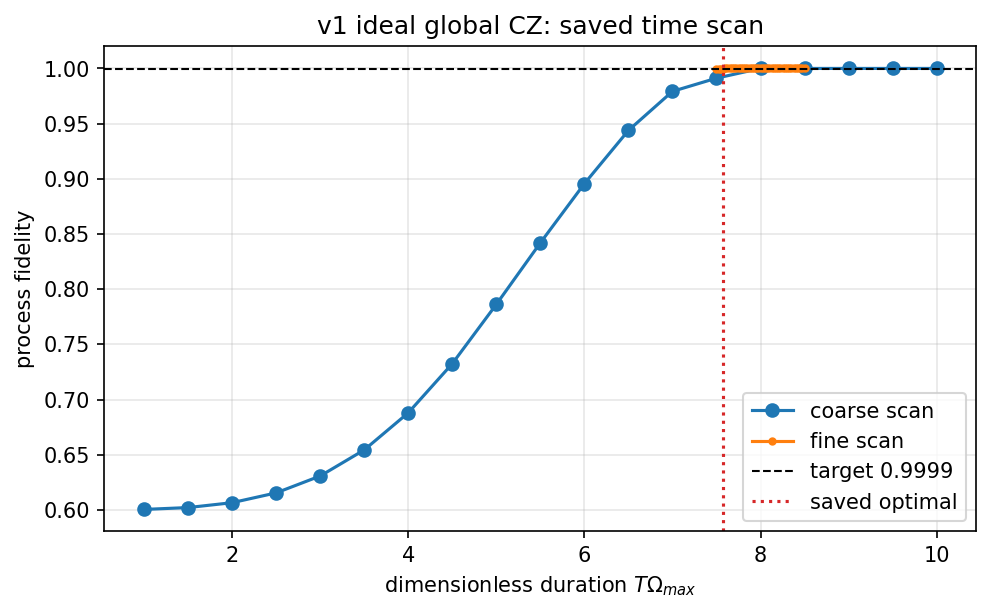

In [8]:
v1_artifacts = v1_artifacts_dir(PROJECT_ROOT)
coarse = json.loads((v1_artifacts / "freeze_v1_global_cz_coarse_scan.json").read_text(encoding="utf-8"))
fine = json.loads((v1_artifacts / "freeze_v1_global_cz_fine_scan.json").read_text(encoding="utf-8"))
optimal = json.loads((v1_artifacts / "freeze_v1_global_cz_optimal.json").read_text(encoding="utf-8"))
fit = json.loads((v1_artifacts / "freeze_v1_global_cz_fit.json").read_text(encoding="utf-8"))

print("coarse points:", len(coarse["durations"]), "best_duration:", coarse["best_duration"])
print("fine points  :", len(fine["durations"]), "best_duration:", fine["best_duration"])
print("optimal evo_time:", optimal["evo_time"])
print("optimal fidelity:", f"{optimal['fidelity']:.12f}")
print("fitted T*Omega_max:", f"{fit['t_star']:.6f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(coarse["durations"], coarse["fidelities"], "o-", label="coarse scan")
ax.plot(fine["durations"], fine["fidelities"], ".-", label="fine scan")
ax.axhline(0.9999, color="black", linestyle="--", linewidth=1.0, label="target 0.9999")
ax.axvline(optimal["evo_time"], color="tab:red", linestyle=":", label="saved optimal")
ax.set_xlabel(r"dimensionless duration $T\Omega_{max}$")
ax.set_ylabel("process fidelity")
ax.set_title("v1 ideal global CZ: saved time scan")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [9]:
# 轻量 API 验证：不追求高保真，只确认 objective、gradient、optimize 调用链可用。
v1_demo_optimizer = ClosedSystemGRAPE.global_phase(
    model=v1_model,
    config=GlobalPhaseOptimizationConfig(
        num_tslots=8,
        evo_time=7.6,
        max_iter=2,
        phase_seed=11,
        init_phase_spread=0.8,
        fidelity_target=0.9999,
    ),
)
variables0 = np.concatenate([np.asarray(v1_demo_optimizer.initial_phases()).ravel(), np.array([0.0])])
objective0, gradient0 = v1_demo_optimizer.objective_and_gradient(variables0)
print(f"initial objective = {objective0:.6f}")
print(f"gradient shape    = {gradient0.shape}")
print(f"gradient norm     = {np.linalg.norm(gradient0):.6f}")

demo_result = v1_demo_optimizer.optimize()
print(f"demo fidelity after 2 L-BFGS iterations = {demo_result.fidelity:.6f}")
print(f"demo theta = {demo_result.theta:.6f}, success flag = {demo_result.success}")


initial objective = 0.961992
gradient shape    = (9,)
gradient norm     = 0.134424
demo fidelity after 2 L-BFGS iterations = 0.115434
demo theta = 0.000000, success flag = False


## Physical model II：Evered 2023 fixed-amplitude phase family

这条线用于验证参数化/带基函数 GRAPE，而不是完整复现实验误差预算。核心相位族是

```text
phi(t) = A cos(omega t - phi0) + delta0 t
```

当前 artifact 的默认解释采用 9D two-photon detuning-gauge Hamiltonian，物理控制是

```text
delta(t) = - d phi / dt
```

并在 paper-Rabi calibration 下加入 leading-order light-shift resonance correction。模型 builder 会生成 two-photon ladder 的 9D Hamiltonian；参数化优化器先对 slot waveform 取 GRAPE 梯度，再链式求 `A, omega, phi0, delta0, theta` 的梯度。

噪声模型方面，当前保留线是闭系统 coherent validation；artifact 中额外报告 Evered-style repeated-gate exponential-decay benchmark，但还不是包含 shot sampling、SPAM、intermediate scattering、laser noise、finite temperature motion 等全部实验层的复现。


In [10]:
pulse = Evered2023TimeOptimalPulse()
cal = Evered2023ParallelCZCalibration()
print("Paper Eq.(1)-style pulse parameters:")
print(f"A / 2pi       = {pulse.amplitude_phase_modulation / (2*np.pi):.6f}")
print(f"omega/Omega   = {pulse.phase_rate:.6f}")
print(f"phi0          = {pulse.phase_offset:.6f} rad")
print(f"Omega*T/2pi   = {pulse.omega_t_over_2pi:.6f}")
print(f"T at Omega/2pi=4.6 MHz: {pulse.physical_duration_seconds(cal.omega_over_2pi_hz)*1e9:.2f} ns")

ideal_evered_model = build_evered2023_ideal_global_cz_model(species=species)
slot_optimizer = ClosedSystemGRAPE.global_phase(
    model=ideal_evered_model,
    config=GlobalPhaseOptimizationConfig(
        num_tslots=200,
        evo_time=pulse.dimensionless_duration,
        max_iter=1,
    ),
)
state = slot_optimizer.final_state(pulse.sampled_phases(slot_optimizer.config.num_tslots))
theta, fid = ideal_evered_model.optimize_theta_for_state(state)
print(f"Ideal 4D check with paper pulse: theta={theta:.6f}, F_pro={fid:.12f}")


Paper Eq.(1)-style pulse parameters:
A / 2pi       = 0.112200
omega/Omega   = 1.043100
phi0          = -0.731800 rad
Omega*T/2pi   = 1.215000
T at Omega/2pi=4.6 MHz: 264.13 ns
Ideal 4D check with paper pulse: theta=2.099040, F_pro=0.999993255553


artifact model: two-photon-detuning
num scan points: 11
target fidelity: 0.9999
best threshold: OmegaT/2pi=1.21, F=0.999936783399, A/2pi=0.111254
best fidelity: 0.999999726068


<tutorial-cell>:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


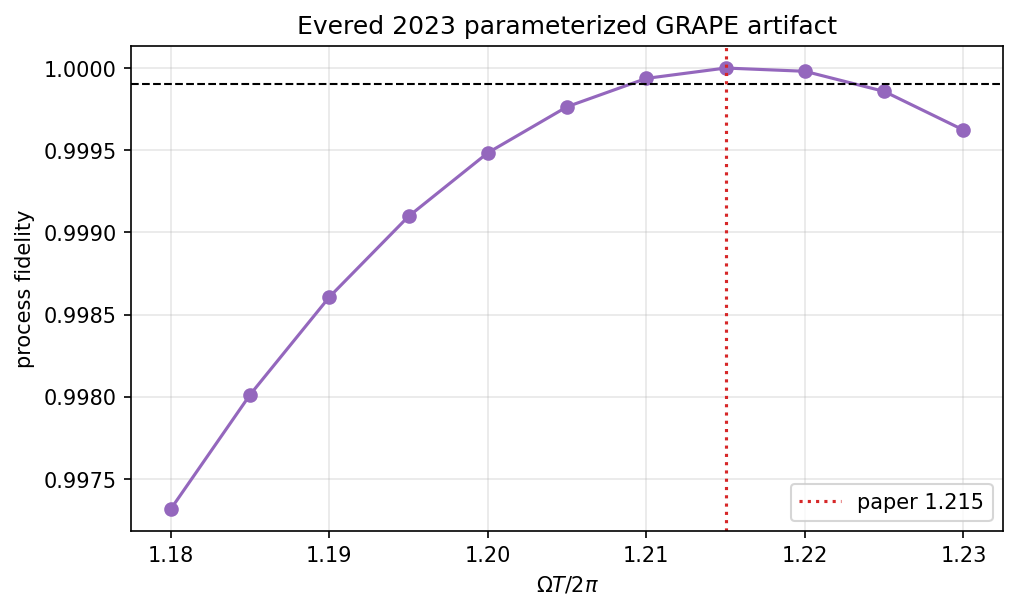

In [11]:
evered_artifacts = evered2023_parallel_cz_dir(PROJECT_ROOT)
evered_scan = json.loads((evered_artifacts / "evered2023_parameterized_grape_scan.json").read_text(encoding="utf-8"))
scan = evered_scan["scan"]
results = scan["results"]
best_threshold = scan["best_threshold_result"]
print("artifact model:", evered_scan["grape_setup"]["model"])
print("num scan points:", len(results))
print("target fidelity:", scan["target_fidelity"])
print(
    "best threshold: "
    f"OmegaT/2pi={best_threshold['omega_t_over_2pi']}, "
    f"F={best_threshold['fidelity']:.12f}, "
    f"A/2pi={best_threshold['amplitude_phase_modulation_over_2pi']:.6f}"
)
print("best fidelity:", f"{scan['best_fidelity_result']['fidelity']:.12f}")

x = [float(row["omega_t_over_2pi"]) for row in results]
y = [float(row["fidelity"]) for row in results]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x, y, "o-", color="tab:purple")
ax.axhline(scan["target_fidelity"], color="black", linestyle="--", linewidth=1.0)
ax.axvline(pulse.omega_t_over_2pi, color="tab:red", linestyle=":", label="paper 1.215")
ax.set_xlabel(r"$\Omega T / 2\pi$")
ax.set_ylabel("process fidelity")
ax.set_title("Evered 2023 parameterized GRAPE artifact")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [12]:
# 参数化优化器的最小调用模板。默认不运行优化；打开开关后会做一个小规模诊断。
RUN_EVERED_DEMO_OPTIMIZATION = False

if RUN_EVERED_DEMO_OPTIMIZATION:
    model_9d = build_evered2023_two_photon_detuning_model(
        species=species,
        intermediate_detuning_over_effective_rabi=cal.intermediate_detuning_hz / cal.omega_over_2pi_hz,
        blockade_shift_over_effective_rabi=cal.blockade_shift_hz / cal.omega_over_2pi_hz,
        blue_rabi_over_effective_rabi=cal.blue_rabi_hz / cal.omega_over_2pi_hz,
        red_rabi_over_effective_rabi=cal.red_rabi_hz / cal.omega_over_2pi_hz,
        static_resonance_shift=(
            (cal.red_rabi_hz / cal.omega_over_2pi_hz) ** 2
            - (cal.blue_rabi_hz / cal.omega_over_2pi_hz) ** 2
        ) / (4.0 * (cal.intermediate_detuning_hz / cal.omega_over_2pi_hz)),
        use_leading_order_dressed_basis=True,
    )
    optimizer_9d = ClosedSystemGRAPE.evered_detuning(
        model=model_9d,
        omega_t_over_2pi=1.21,
        config=Evered2023ParameterizedGRAPEConfig(
            num_tslots=40,
            max_iter=5,
            num_restarts=1,
            include_paper_seed=True,
            fix_static_detuning=True,
            fidelity_target=0.999,
        ),
    )
    result_9d = optimizer_9d.optimize()
    pprint(result_9d.to_json())
else:
    print("Set RUN_EVERED_DEMO_OPTIMIZATION=True to run a small 9D parameterized GRAPE diagnostic.")
    print("For the maintained reproduction, prefer the command shown in the Outputs section.")


Set RUN_EVERED_DEMO_OPTIMIZATION=True to run a small 9D parameterized GRAPE diagnostic.
For the maintained reproduction, prefer the command shown in the Outputs section.


## Physical model III：`^{171}Yb` shelved control-Rydberg UV edge scan

这条线来自 `yb171_closed_cr_edge_time_optimal_scan.ipynb`，现在已抽到 `src`。Reduced basis 是

```text
|00>, |0c>, |0r>, |cc>, |W_cr>, |rr>
```

其中 `|c>` 表示 shelving 后参与 control-Rydberg 段的 clock/control 态，`|r>` 表示 Rydberg 态。计算子空间评分只取三个 diagonal branch：`|00>`, `|0c>/<c0>`, `|cc>`，用权重 `(1, 2, 1)` 映射回完整 4D computational diagonal。

Hamiltonian 仍是 phase-only direct control：

```text
H(t) = H_d + A(t) [cos(phi_k) H_x + sin(phi_k) H_y]
```

`A(t)` 是 UV Gaussian edge envelope；`H_d` 含 `|rr>` blockade shift；`H_x, H_y` 含 `|0c><0r|`, `|cc><W_cr|`, `|W_cr><rr|` 耦合。时间单位由 `omega_max_mhz` 和 `total_time_ns` 转成无量纲传播时间。


### Noise model, objective, and validation for UV edge scan

当前 dense artifact 使用 Rydberg decay 的 no-jump non-Hermitian 近似：

```text
G = -i H - 1/2 diag(0, 0, gamma, 0, gamma, 2 gamma)
```

默认 `rydberg_lifetime_s = 65e-6`，`blockade_shift_mhz = 160`。优化目标是 no-jump Kraus operator 限制到 computational diagonal 后的 process fidelity：

```text
F_pro = |Tr(D_CZ^dagger K_comp)|^2 / 16
```

`active_population` 和 `loss_proxy` 是诊断量。dense scan 的验证方式包括：可重读 JSON/CSV artifact、summary 由 raw rows 重新计算一致、轻量梯度/objective 调用可运行、并保留了用于人工检查的 PNG 曲线和 phase traces。


In [13]:
uv_artifacts = yb171_uv_edge_artifacts_dir(PROJECT_ROOT)
uv_config = UVDenseEdgeScanConfig(output_dir=uv_artifacts)
rows, summary, selected_rows = load_uv_edge_artifacts(uv_config)
print("UV scan rows:", len(rows))
print("summary rows:", len(summary))
print("metadata:")
pprint(config_metadata(uv_config))

# 重新汇总一次，确认 raw rows -> summary 的核心统计字段与已保存结果一致。
# 保存的 summary artifact 额外包含 num_tslots/max_iter 等运行元数据，所以不能直接比较整行 dict。
summary_core_keys = [
    "omega_max_mhz",
    "edge_ns",
    "shortest_passing_time_ns",
    "first_passing_fidelity",
    "best_time_ns",
    "best_fidelity",
    "scanned_times_ns",
]

def core_summary(row: dict[str, object]) -> dict[str, object]:
    return {key: row.get(key) for key in summary_core_keys}

recomputed_summary, recomputed_selected = summarize_uv_edge_rows(rows)
saved_summary_core = [core_summary(row) for row in summary]
recomputed_summary_core = [core_summary(row) for row in recomputed_summary]
print("recomputed core summary matches saved:", recomputed_summary_core == saved_summary_core)
print("recomputed selected rows matches saved:", recomputed_selected == selected_rows)

print("\nFirst six summary rows:")
for row in summary[:6]:
    print(
        f"Omega={row['omega_max_mhz']:>4.0f} MHz, edge={row['edge_ns']:>4.0f} ns, "
        f"shortest passing={row['shortest_passing_time_ns']}, "
        f"best=({row['best_time_ns']} ns, F={row['best_fidelity']:.9f})"
    )


UV scan rows: 123
summary rows: 15
metadata:
{'blockade_shift_mhz': 160.0,
 'curvature_weight': 0.0001,
 'fidelity_definition': 'no-jump Kraus process fidelity |Tr(D_CZ^dagger '
                        'K_comp)|^2 / 16',
 'max_iter': 360,
 'noise_model': 'Rydberg decay as non-Hermitian no-jump term',
 'num_tslots': 64,
 'regularization_model': 'wrapped first- and second-difference phase penalty',
 'rydberg_lifetime_s': 6.5e-05,
 'smoothness_weight': 0.0001,
 'threshold': 0.999,
 'uses_basis_functions': False,
 'uses_regularization': True}
recomputed core summary matches saved: True
recomputed selected rows matches saved: True

First six summary rows:
Omega=   5 MHz, edge=   0 ns, shortest passing=None, best=(260.0 ns, F=0.998546941)
Omega=   5 MHz, edge=  10 ns, shortest passing=None, best=(260.0 ns, F=0.998573666)
Omega=   5 MHz, edge=  20 ns, shortest passing=None, best=(280.0 ns, F=0.998564022)
Omega=   5 MHz, edge=  40 ns, shortest passing=None, best=(300.0 ns, F=0.998567529)
Omega

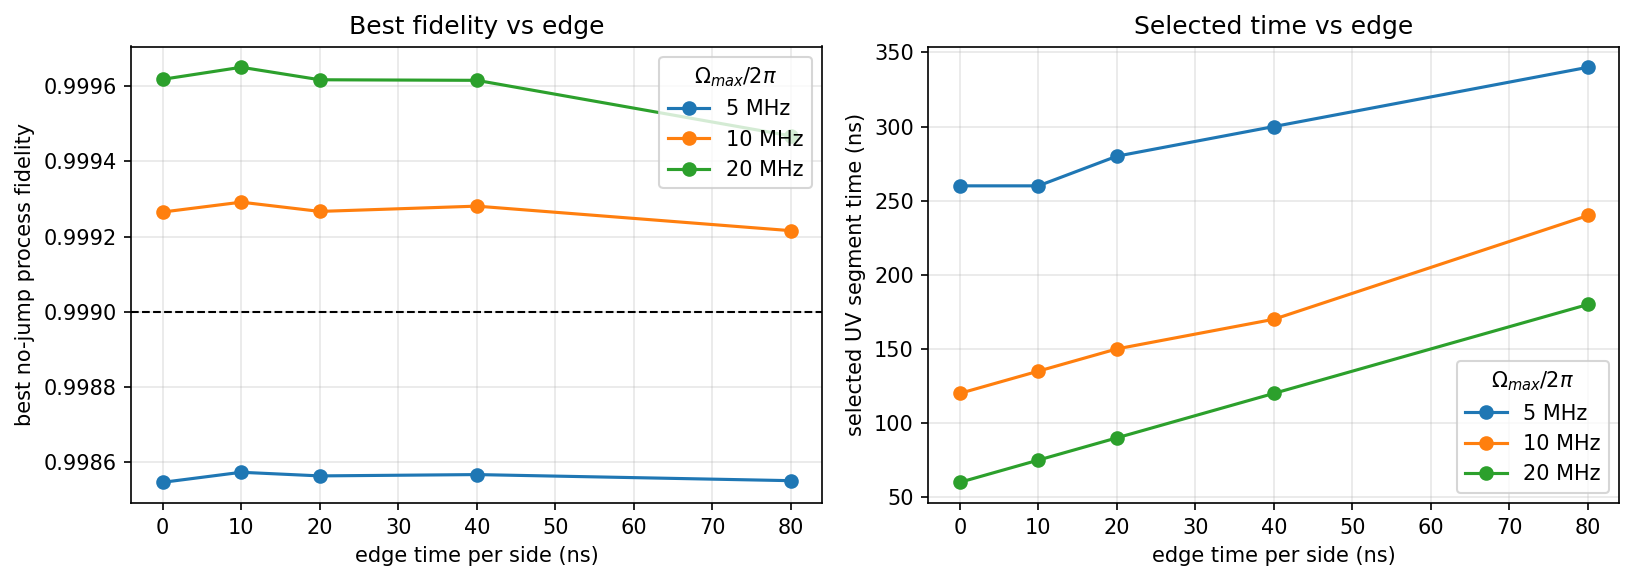

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
for omega in sorted({float(row["omega_max_mhz"]) for row in summary}):
    group = sorted([row for row in summary if float(row["omega_max_mhz"]) == omega], key=lambda r: float(r["edge_ns"]))
    edges = [float(row["edge_ns"]) for row in group]
    best_f = [float(row["best_fidelity"]) for row in group]
    selected_t = [
        float(row["shortest_passing_time_ns"]) if row["shortest_passing_time_ns"] is not None else float(row["best_time_ns"])
        for row in group
    ]
    axes[0].plot(edges, best_f, "o-", label=f"{omega:g} MHz")
    axes[1].plot(edges, selected_t, "o-", label=f"{omega:g} MHz")
axes[0].axhline(uv_config.threshold, color="black", linestyle="--", linewidth=1.0)
axes[0].set_xlabel("edge time per side (ns)")
axes[0].set_ylabel("best no-jump process fidelity")
axes[0].set_title("Best fidelity vs edge")
axes[1].set_xlabel("edge time per side (ns)")
axes[1].set_ylabel("selected UV segment time (ns)")
axes[1].set_title("Selected time vs edge")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(title=r"$\Omega_{max}/2\pi$")
fig.tight_layout()
plt.show()


In [15]:
# 轻量 API 验证：构建一个 no-jump GRAPE 对象并检查 envelope、objective、gradient。
small_uv_cfg = ShelvedCRPhaseGRAPEConfig(
    omega_max_mhz=10.0,
    total_time_ns=120.0,
    edge_time_ns=20.0,
    num_tslots=8,
    blockade_shift_mhz=160.0,
    smoothness_weight=1e-4,
    curvature_weight=1e-4,
    rydberg_lifetime_s=65e-6,
)
small_uv = ClosedSystemGRAPE.shelved_cr_phase(small_uv_cfg, include_rydberg_decay=True)
variables0 = small_uv.initial_guess(seed=123)
evaluated0 = small_uv.evaluate(variables0)
objective0, gradient0 = small_uv.objective_and_gradient(variables0)
print("envelope:", np.array2string(small_uv.envelope, precision=3))
print(f"initial process fidelity = {evaluated0['process_fidelity']:.6f}")
print(f"active population        = {evaluated0['active_population']:.6f}")
print(f"objective                = {objective0:.6f}")
print(f"gradient shape/norm      = {gradient0.shape}, {np.linalg.norm(gradient0):.6f}")
print("dense_time_is_allowed(120, 80) ->", dense_time_is_allowed(120.0, 80.0))
print("dense_time_is_allowed(240, 80) ->", dense_time_is_allowed(240.0, 80.0))


envelope: [0.    0.911 1.    1.    1.    1.    0.911 0.   ]
initial process fidelity = 0.028450
active population        = 0.720478
objective                = 0.971749
gradient shape/norm      = (10,), 0.086136
dense_time_is_allowed(120, 80) -> False
dense_time_is_allowed(240, 80) -> True


In [16]:
# 完整 dense scan 会优化 100+ 个点，默认不在教程里自动运行。
# 如需快速检查写出/读入/summary/plot 全链条，可打开 smoke scan。
RUN_UV_SMOKE_SCAN = False

if RUN_UV_SMOKE_SCAN:
    smoke_dir = uv_artifacts / "tutorial_smoke"
    smoke_config = UVDenseEdgeScanConfig(
        output_dir=smoke_dir,
        time_grids_ns={10.0: [60.0, 80.0]},
        edge_values_ns=[0.0, 10.0],
        num_tslots=8,
        max_iter=2,
        threshold=0.95,
    )
    smoke_rows = run_uv_edge_scan(smoke_config)
    smoke_summary, smoke_selected = summarize_uv_edge_rows(smoke_rows)
    write_uv_edge_artifacts(smoke_config, smoke_rows, smoke_summary, smoke_selected)
    print("smoke artifacts written to", smoke_dir)
else:
    print("Set RUN_UV_SMOKE_SCAN=True for a two-edge/two-time fast scan.")
    print("For the maintained dense result, load existing artifacts or run experiments/scan_yb171_uv_edge_effect.py.")


Set RUN_UV_SMOKE_SCAN=True for a two-edge/two-time fast scan.
For the maintained dense result, load existing artifacts or run experiments/scan_yb171_uv_edge_effect.py.


## How to adapt this tutorial to other problems

最稳妥的改法是只改一层参数，并保持 artifact 目录可追溯：

1. 改物理标尺：优先改 builder 或 `Config` 中的 `omega_max_mhz`, `blockade_shift_mhz`, `rydberg_lifetime_s`, detuning ratios、Rabi ratios。
2. 改控制参数：改 `num_tslots`, `total_time_ns`, `edge_time_ns`, phase-family duration `omega_t_over_2pi`，不要直接改优化器内部数组。
3. 改优化强度：先小 `max_iter` 和少量 `num_restarts` 做 smoke，再扩大到 artifact 级别。dense scan 运行前预估点数和每点耗时。
4. 改 objective 或噪声：应在 `src/neutral_yb/optimization/` 或 `src/neutral_yb/models/` 新增清晰类，并用 `tests/` 做梯度/极限检查，不要只在 notebook cell 里改。
5. 保存结果：写到新的描述性目录，例如 `artifacts/v5/my_new_scan_YYYYMMDD/`，不要覆盖当前冻结结果。

判断一个新问题是否可以复用现有 API：如果 Hilbert basis、评分 diagonal branch、控制 waveform 或 noise generator 没变，只需要改 `Config`；如果计算子空间、collapse/no-jump 项或 Hamiltonian 结构变了，应新增模型/优化器并补测试。


## Outputs and exact reproduction commands

已保存 artifact 位置：

```text
artifacts/v1/
artifacts/evered2023_parallel_cz/
artifacts/v5/closed_cr_edge_time_optimal_scan/
```

从命令行复现当前维护结果：

```bash
cd ~/projects/Noise-Tolerant-Quantum-Control-Optimization
./.venv/bin/python experiments/freeze_v1_global_cz_reference.py
./.venv/bin/python experiments/reproduce_evered2023_parallel_cz_gate.py \
  --model two-photon-detuning \
  --rabi-calibration paper \
  --light-shift-resonance \
  --dressed-basis \
  --include-paper-seed
./.venv/bin/python scripts/plot_evered2023_parallel_cz.py
./.venv/bin/python experiments/scan_yb171_uv_edge_effect.py --replot
```

`UV edge` 完整重跑使用：

```bash
./.venv/bin/python experiments/scan_yb171_uv_edge_effect.py --recompute
```

完整重跑会优化大量 GRAPE 点，应在确认参数、输出目录和运行预算后再执行。


In [17]:
print("Verification summary from saved artifacts:")
print(f"v1 optimal: T*Omega={optimal['evo_time']}, F={optimal['fidelity']:.12f}")
print(f"v1 fitted threshold time: T*Omega={fit['t_star']:.6f}")
print(
    "Evered best threshold: "
    f"OmegaT/2pi={scan['best_threshold_result']['omega_t_over_2pi']}, "
    f"F={scan['best_threshold_result']['fidelity']:.12f}"
)
print(
    "UV dense scan: "
    f"{len(rows)} raw rows, {len(summary)} summary rows, "
    f"threshold={uv_config.threshold}"
)

commands = [
    "./.venv/bin/python -m unittest tests.test_global_cz_4d tests.test_evered2023_parallel_cz tests.test_shelved_cr_phase_grape -v",
    "./.venv/bin/python experiments/scan_yb171_uv_edge_effect.py --smoke",
]
print("\nRecommended quick checks before changing the API:")
for command in commands:
    print("  " + command)


Verification summary from saved artifacts:
v1 optimal: T*Omega=7.575, F=0.999916049919
v1 fitted threshold time: T*Omega=7.613153
Evered best threshold: OmegaT/2pi=1.21, F=0.999936783399
UV dense scan: 123 raw rows, 15 summary rows, threshold=0.999

Recommended quick checks before changing the API:
  ./.venv/bin/python -m unittest tests.test_global_cz_4d tests.test_evered2023_parallel_cz tests.test_shelved_cr_phase_grape -v
  ./.venv/bin/python experiments/scan_yb171_uv_edge_effect.py --smoke


## Validation notes and limits

本教程的验证结果来自三类证据：

- `v1`：无噪声 4D 极限中，保存的 fine scan 达到 `F >= 0.9999`，并给出 `T Omega_max` 的阈值附近拟合。
- `Evered 2023`：paper Eq. (1) pulse 在 ideal 4D 模型中给出接近 1 的 process fidelity；当前 9D detuning-gauge artifact 保存了 parameterized GRAPE scan 和 paper-style benchmark。
- `^{171}Yb` UV edge：从 raw rows 重新汇总得到的 summary 与保存 artifact 一致；轻量 no-jump GRAPE objective/gradient 可调用。

限制也要明确：本教程默认读取已有 artifact，不替你完成长时间 dense recompute；UV 线使用 no-jump non-Hermitian 近似，不是完整 Lindblad master equation；Evered 线是 closed-system/benchmarking validation，不包含完整实验噪声、SPAM 和 shot model。若要把这些物理层加入新问题，应先新增模型和测试，再把 notebook 作为说明与审查记录。
